# Calidad del aire en Bogotá — Mapa por localidad
**Paso 1:** mapa coroplético interactivo (Plotly) del IBOCA promedio por localidad.

Corre las celdas en orden. Te pedirá subir `reporteIboca.xlsx` en la celda 2.

In [3]:
# Si Colab te dice que falta plotly, descomenta la siguiente línea:
# !pip install plotly --quiet

import requests
import pandas as pd
import numpy as np
import plotly.express as px
from google.colab import files


## 1. Sube `reporteIboca.xlsx`

In [4]:
subido = files.upload()
ruta_archivo = list(subido.keys())[0]
ruta_archivo


Saving reporteIboca.xlsx to reporteIboca (1).xlsx


'reporteIboca (1).xlsx'

## 2. Limpiar el reporte y calcular el IBOCA promedio por localidad

In [5]:
estaciones_orden = ["Bolivia", "CDAR", "Colina", "Fontibon", "Guaymaral", "Kennedy",
                     "Las Ferias", "MinAmbiente", "Móvil 7ma", "Móvil Fontibón",
                     "San Cristobal", "Tunal", "Usaquen", "Usme", "Puente Aranda",
                     "Ciudad Bolívar", "Suba", "Carvajal - Sevillana", "Jazmín"]

cols = ["fecha_hora"]
for e in estaciones_orden:
    cols += [f"{e}__conc", f"{e}__nowcast", f"{e}__iboca"]

raw = pd.read_excel(ruta_archivo, sheet_name=0, header=None, skiprows=7, nrows=4321)
raw.columns = cols
raw["fecha_hora"] = pd.to_datetime(raw["fecha_hora"], errors="coerce")
raw = raw.dropna(subset=["fecha_hora"]).drop_duplicates(subset=["fecha_hora"]).sort_values("fecha_hora")

filas = []
for e in estaciones_orden:
    sub = raw[["fecha_hora", f"{e}__conc", f"{e}__nowcast", f"{e}__iboca"]].copy()
    sub.columns = ["fecha_hora", "concentracion", "nowcast", "iboca"]
    for c in ["concentracion", "nowcast", "iboca"]:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
    sub["estacion"] = e
    filas.append(sub)
df = pd.concat(filas, ignore_index=True)

localidad_map = {
    "Guaymaral": "Suba", "Suba": "Suba", "Colina": "Suba",
    "Bolivia": "Engativá", "Las Ferias": "Engativá", "CDAR": "Engativá",
    "Móvil 7ma": "Chapinero", "MinAmbiente": "Santa Fe",
    "Fontibon": "Fontibón", "Móvil Fontibón": "Fontibón",
    "Puente Aranda": "Puente Aranda", "Jazmín": "Puente Aranda",
    "Kennedy": "Kennedy", "Carvajal - Sevillana": "Kennedy",
    "Tunal": "Tunjuelito", "San Cristobal": "San Cristóbal",
    "Usme": "Usme", "Ciudad Bolívar": "Ciudad Bolívar", "Usaquen": "Usaquén",
}
df["localidad"] = df["estacion"].map(localidad_map)

prom_localidad = (df.groupby("localidad")["iboca"]
                     .mean()
                     .round(1)
                     .reset_index(name="iboca_promedio"))
prom_localidad


,localidad,iboca_promedio
0,Chapinero,53.4
1,Ciudad Bolívar,54.8
2,Engativá,57.5
3,Fontibón,50.1
4,Kennedy,50.8
5,Puente Aranda,47.8
6,San Cristóbal,47.6
7,Santa Fe,53.2
8,Suba,50.5
9,Tunjuelito,48.0


## 3. Descargar el polígono oficial de las localidades
Fuente: Secretaría Distrital de Planeación / IDECA — Mapa de Referencia del Distrito Capital (`Mapa_referencia_/FeatureServer`, capa *Localidad*).

In [6]:
url = ("https://services.arcgis.com/deQSb0Gn7gDPf3uV/ArcGIS/rest/services/"
       "Mapa_referencia_/FeatureServer/3/query")
params = {
    "where": "1=1",
    "outFields": "LocNombre,LocCodigo",
    "outSR": "4326",
    "geometryPrecision": 5,
    "f": "geojson",
}
resp = requests.get(url, params=params, timeout=30)
geo_localidades = resp.json()
len(geo_localidades["features"])  # debería dar 19


19

In [7]:
# El servicio trae los nombres en MAYÚSCULAS y sin tilde -> los normalizamos
# para que calcen exactamente con los nombres de nuestra tabla de IBOCA.
normaliza = {
    "ANTONIO NARIÑO": "Antonio Nariño", "BARRIOS UNIDOS": "Barrios Unidos",
    "BOSA": "Bosa", "CANDELARIA": "Candelaria", "CHAPINERO": "Chapinero",
    "CIUDAD BOLIVAR": "Ciudad Bolívar", "ENGATIVA": "Engativá",
    "FONTIBON": "Fontibón", "KENNEDY": "Kennedy", "LOS MARTIRES": "Los Mártires",
    "PUENTE ARANDA": "Puente Aranda", "RAFAEL URIBE URIBE": "Rafael Uribe Uribe",
    "SAN CRISTOBAL": "San Cristóbal", "SANTA FE": "Santa Fe", "SUBA": "Suba",
    "TEUSAQUILLO": "Teusaquillo", "TUNJUELITO": "Tunjuelito",
    "USAQUEN": "Usaquén", "USME": "Usme",
}
for feat in geo_localidades["features"]:
    nombre_original = feat["properties"]["LocNombre"]
    feat["properties"]["localidad"] = normaliza.get(nombre_original, nombre_original.title())

# El reto solo tiene estaciones en 12 de las 20 localidades; completamos las
# demás con NaN para que salgan en gris -- así queda claro dónde SÍ hay dato.
todas_localidades = pd.DataFrame(
    {"localidad": [f["properties"]["localidad"] for f in geo_localidades["features"]]}
)
prom_localidad = todas_localidades.merge(prom_localidad, on="localidad", how="left")
prom_localidad


,localidad,iboca_promedio
0,Antonio Nariño,NaN
1,Tunjuelito,48.0
2,Rafael Uribe Uribe,NaN
3,Candelaria,NaN
4,Barrios Unidos,NaN
5,Teusaquillo,NaN
6,Puente Aranda,47.8
7,Los Mártires,NaN
8,Usaquén,47.5
9,Chapinero,53.4


## 4. El mapa (interactivo: pasa el mouse por cada localidad)

In [8]:
colores_iboca = ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C", "#8E44AD"]

fig = px.choropleth_mapbox(
    prom_localidad,
    geojson=geo_localidades,
    locations="localidad",
    featureidkey="properties.localidad",
    color="iboca_promedio",
    color_continuous_scale=colores_iboca,
    range_color=(0, 200),
    mapbox_style="carto-positron",
    center={"lat": 4.65, "lon": -74.10},
    zoom=9.3,
    opacity=0.85,
    hover_name="localidad",
    hover_data={"iboca_promedio": ":.1f", "localidad": False},
    labels={"iboca_promedio": "IBOCA promedio"},
)
fig.update_layout(
    title="Calidad del aire en Bogotá por localidad<br><sup>IBOCA promedio de PM2.5 · enero-junio 2025</sup>",
    margin={"r": 0, "t": 60, "l": 0, "b": 0},
    coloraxis_colorbar=dict(title="IBOCA<br>promedio"),
)
fig.show()


In [9]:
estaciones_orden = ["Bolivia", "CDAR", "Colina", "Fontibon", "Guaymaral", "Kennedy",
                     "Las Ferias", "MinAmbiente", "Móvil 7ma", "Móvil Fontibón",
                     "San Cristobal", "Tunal", "Usaquen", "Usme", "Puente Aranda",
                     "Ciudad Bolívar", "Suba", "Carvajal - Sevillana", "Jazmín"]

cols = ["fecha_hora"]
for e in estaciones_orden:
    cols += [f"{e}__conc", f"{e}__nowcast", f"{e}__iboca"]

raw = pd.read_excel(ruta_archivo, sheet_name=0, header=None, skiprows=7, nrows=4321)
raw.columns = cols
raw["fecha_hora"] = pd.to_datetime(raw["fecha_hora"], errors="coerce")
raw = raw.dropna(subset=["fecha_hora"]).drop_duplicates(subset=["fecha_hora"]).sort_values("fecha_hora")

filas = []
for e in estaciones_orden:
    sub = raw[["fecha_hora", f"{e}__conc", f"{e}__nowcast", f"{e}__iboca"]].copy()
    sub.columns = ["fecha_hora", "concentracion", "nowcast", "iboca"]
    for c in ["concentracion", "nowcast", "iboca"]:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
    sub["estacion"] = e
    filas.append(sub)
df = pd.concat(filas, ignore_index=True)

localidad_map = {
    "Guaymaral": "Suba", "Suba": "Suba", "Colina": "Suba",
    "Bolivia": "Engativá", "Las Ferias": "Engativá", "CDAR": "Engativá",
    "Móvil 7ma": "Chapinero", "MinAmbiente": "Santa Fe",
    "Fontibon": "Fontibón", "Móvil Fontibón": "Fontibón",
    "Puente Aranda": "Puente Aranda", "Jazmín": "Puente Aranda",
    "Kennedy": "Kennedy", "Carvajal - Sevillana": "Kennedy",
    "Tunal": "Tunjuelito", "San Cristobal": "San Cristóbal",
    "Usme": "Usme", "Ciudad Bolívar": "Ciudad Bolívar", "Usaquen": "Usaquén",
}
df["localidad"] = df["estacion"].map(localidad_map)

df["hora"] = df["fecha_hora"].dt.hour
df["dia_semana"] = df["fecha_hora"].dt.day_name()
df["semana"] = df["fecha_hora"].dt.to_period("W").apply(lambda p: p.start_time)
df["tipo_dia"] = np.where(df["dia_semana"].isin(["Saturday","Sunday"]), "Fin de semana", "Entre semana")

cortes = [0, 50, 100, 150, 200, 500]
etiquetas = ["Favorable", "Moderada", "Regular", "Mala", "Peligrosa"]
colores_iboca = {"Favorable": "#2ECC71", "Moderada": "#F1C40F", "Regular": "#E67E22",
                 "Mala": "#E74C3C", "Peligrosa": "#8E44AD"}
df["categoria_iboca"] = pd.cut(df["iboca"], bins=cortes, labels=etiquetas, include_lowest=True)

print("Filas:", len(df), "| Localidades:", df["localidad"].nunique(),
      "| % IBOCA válido:", round(df["iboca"].notna().mean()*100,1))

Filas: 82099 | Localidades: 12 | % IBOCA válido: 80.2


,Localidad,IBOCA promedio,Categoría
0,Engativá,57.5,Moderada
1,Ciudad Bolívar,54.8,Moderada
2,Chapinero,53.4,Moderada
3,Santa Fe,53.2,Moderada
4,Kennedy,50.8,Moderada
5,Suba,50.5,Moderada
6,Fontibón,50.1,Moderada
7,Tunjuelito,48.0,Favorable
8,Puente Aranda,47.8,Favorable
9,San Cristóbal,47.6,Favorable


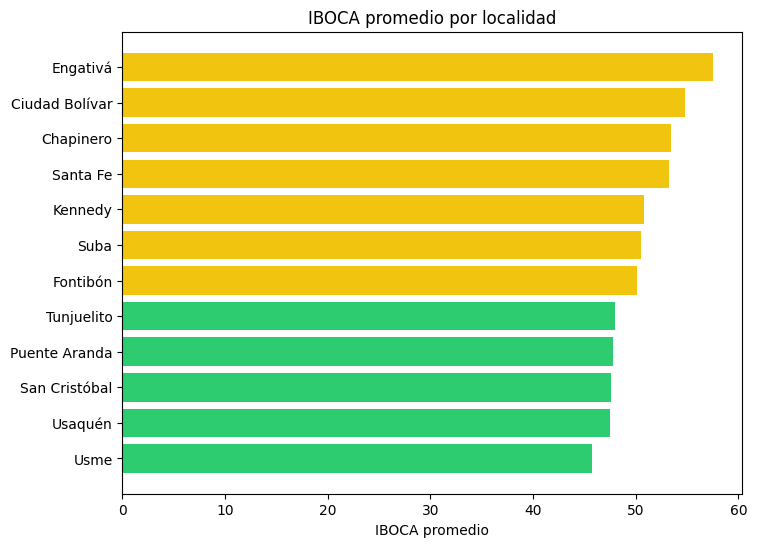

In [10]:
import matplotlib.pyplot as plt
p1 = df.groupby("localidad")["iboca"].mean().sort_values(ascending=False).round(1).reset_index()
p1.columns = ["Localidad", "IBOCA promedio"]
p1["Categoría"] = pd.cut(p1["IBOCA promedio"], bins=cortes, labels=etiquetas, include_lowest=True)
display(p1)

fig, ax = plt.subplots(figsize=(8,6))
colors = [colores_iboca[c] for c in p1["Categoría"]]
ax.barh(p1["Localidad"][::-1], p1["IBOCA promedio"][::-1], color=colors[::-1])
ax.set_xlabel("IBOCA promedio"); ax.set_title("IBOCA promedio por localidad")
plt.show()

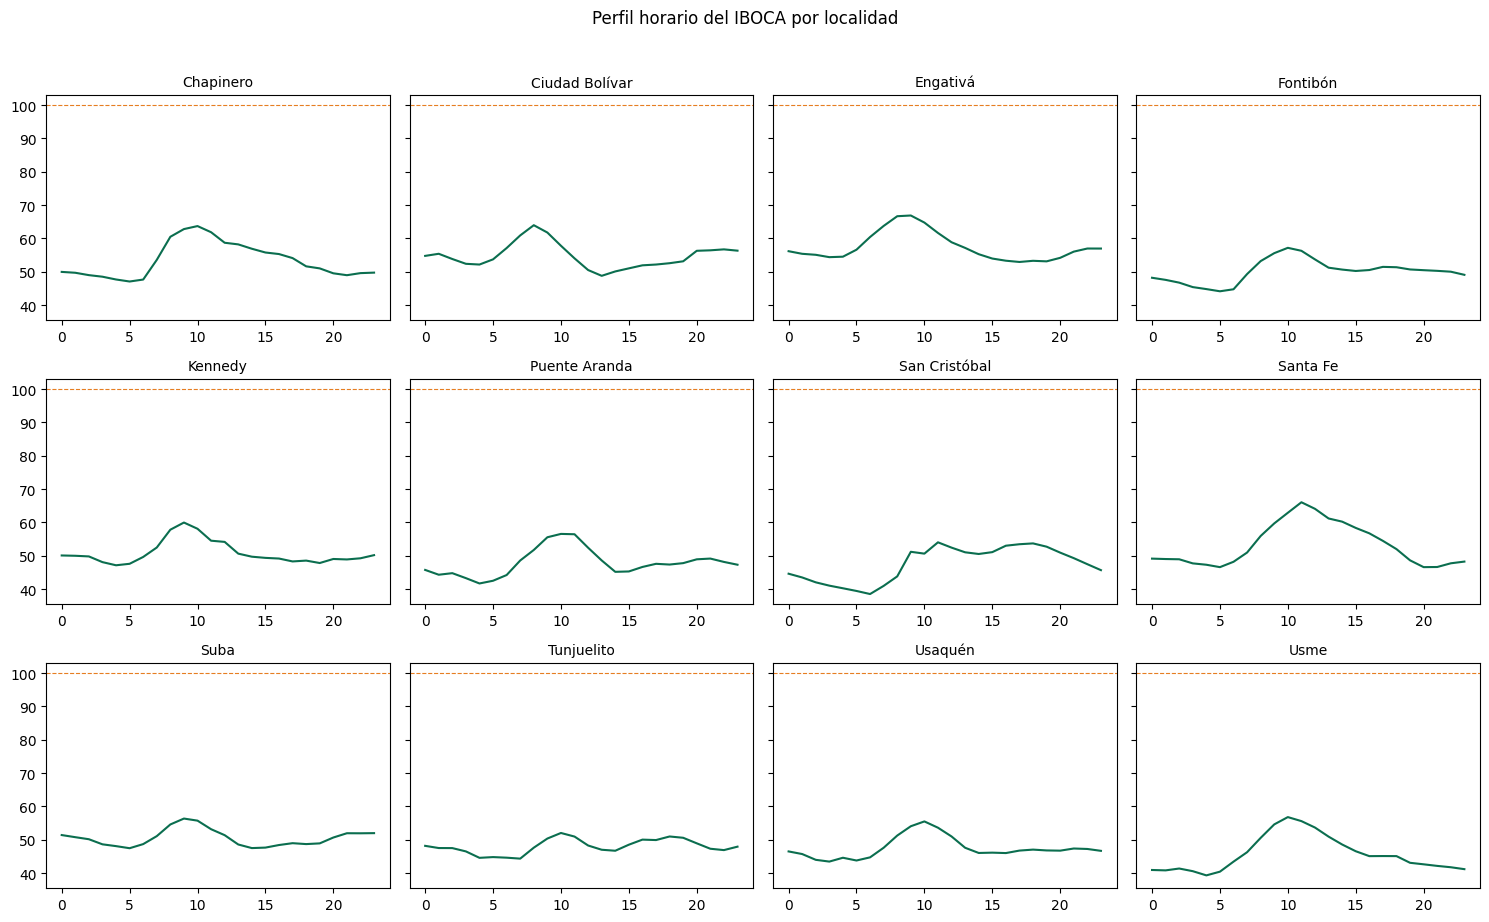

In [11]:
p2 = df.groupby(["localidad","hora"])["iboca"].mean().reset_index()
localidades = sorted(df["localidad"].dropna().unique())
fig, axes = plt.subplots(3,4, figsize=(15,9), sharey=True)
for ax, loc in zip(axes.flat, localidades):
    sub = p2[p2.localidad==loc]
    ax.plot(sub.hora, sub.iboca, color="#0B6E4F")
    ax.axhline(100, color="#E67E22", linestyle="--", linewidth=0.8)
    ax.set_title(loc, fontsize=10)
fig.suptitle("Perfil horario del IBOCA por localidad", y=1.02)
fig.tight_layout(); plt.show()

periodo,Abr-Jun,Ene-Mar,Cambio
localidad,,,
Puente Aranda,32.6,63.8,-31.2
Usme,35.6,59.7,-24.1
Fontibón,40.8,60.3,-19.5
Suba,41.1,59.8,-18.7
Tunjuelito,40.9,58.0,-17.1
Usaquén,40.8,56.9,-16.1
San Cristóbal,40.7,56.5,-15.8
Ciudad Bolívar,46.0,61.8,-15.8
Santa Fe,46.0,61.2,-15.2


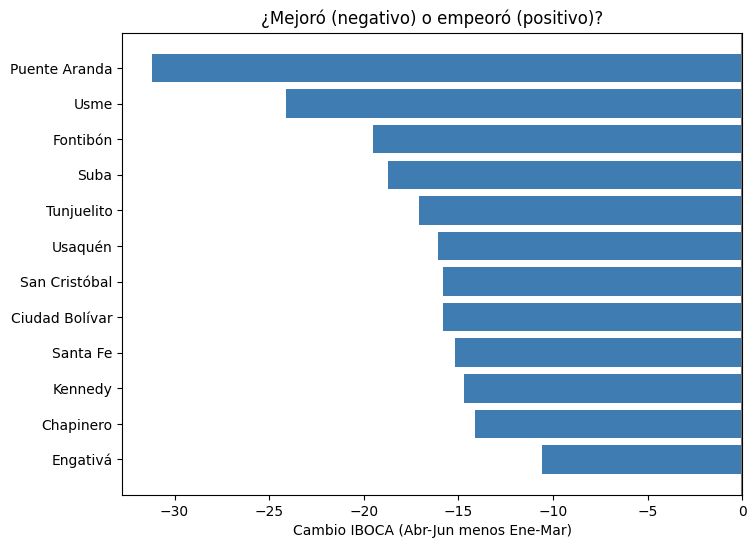

In [12]:
df["periodo"] = np.where(df["fecha_hora"] < "2025-04-01", "Ene-Mar", "Abr-Jun")
p3 = df.groupby(["localidad","periodo"])["iboca"].mean().unstack().round(1)
p3["Cambio"] = (p3["Abr-Jun"]-p3["Ene-Mar"]).round(1)
p3 = p3.sort_values("Cambio")
display(p3)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(p3.index[::-1], p3["Cambio"][::-1], color="#3E7CB1")
ax.axvline(0, color="grey"); ax.set_xlabel("Cambio IBOCA (Abr-Jun menos Ene-Mar)")
ax.set_title("¿Mejoró (negativo) o empeoró (positivo)?")
plt.show()

categoria_iboca,Favorable,Moderada,Regular,Mala,Peligrosa
localidad,,,,,
Chapinero,42.2,54.4,3.4,0.1,0.0
Ciudad Bolívar,37.3,61.0,1.6,0.1,0.0
Engativá,39.0,52.6,7.4,1.1,0.0
Fontibón,46.5,51.1,2.2,0.2,0.0
Kennedy,44.5,53.1,2.2,0.1,0.1
Puente Aranda,51.0,47.0,1.8,0.1,0.0
San Cristóbal,52.0,46.0,1.8,0.1,0.0
Santa Fe,40.7,55.5,3.6,0.1,0.0
Suba,45.8,52.0,2.2,0.1,0.0


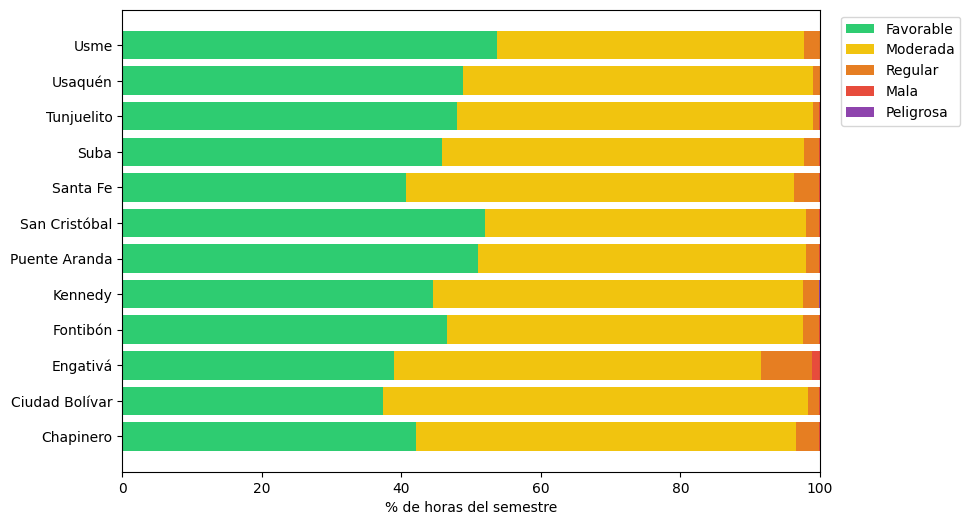

In [13]:
p4 = df.dropna(subset=["categoria_iboca"]).groupby(["localidad","categoria_iboca"], observed=True).size().reset_index(name="n")
p4["pct"] = p4.groupby("localidad")["n"].transform(lambda x: x/x.sum()*100)
piv4 = p4.pivot(index="localidad", columns="categoria_iboca", values="pct").fillna(0)[etiquetas]
display(piv4.round(1))

fig, ax = plt.subplots(figsize=(9,6))
left = np.zeros(len(piv4))
for cat in etiquetas:
    ax.barh(piv4.index, piv4[cat], left=left, color=colores_iboca[cat], label=cat)
    left += piv4[cat].values
ax.legend(bbox_to_anchor=(1.02,1)); ax.set_xlabel("% de horas del semestre")
plt.show()

mean  median   std
localidad     estacion                                
Engativá      Bolivia               43.0    43.7  24.1
              CDAR                  78.1    77.9  32.7
              Las Ferias            51.1    53.4  23.4
Fontibón      Fontibon              51.9    54.5  25.8
              Móvil Fontibón        48.3    51.3  24.7
Kennedy       Carvajal - Sevillana  44.1    47.2  20.5
              Kennedy               53.9    55.4  24.4
Puente Aranda Jazmín                48.8    51.6  28.3
              Puente Aranda         47.6    48.2  25.2
Suba          Colina                46.9    48.8  24.8
              Guaymaral             50.5    53.0  22.3
              Suba                  57.2    56.8  25.3

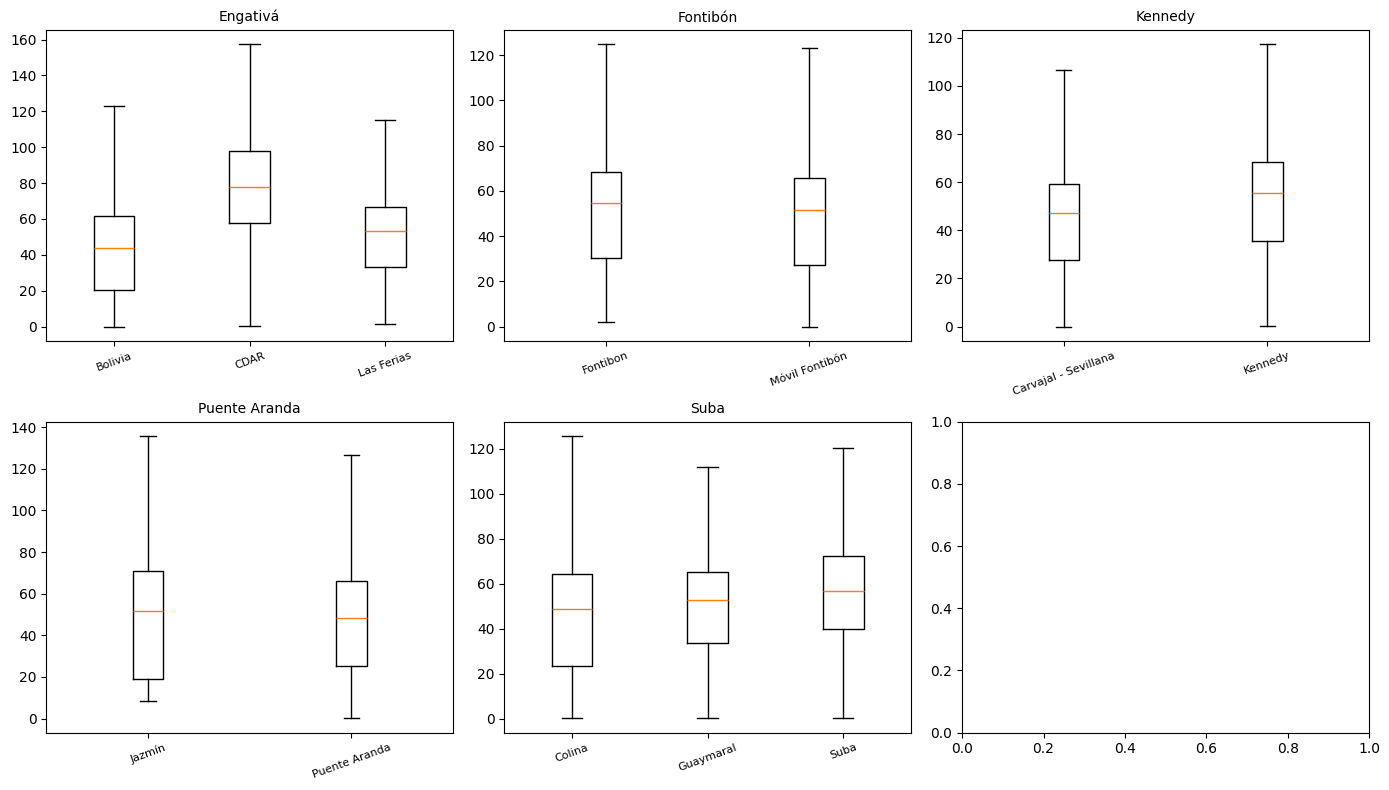

In [14]:
localidades_varias = df.groupby("localidad")["estacion"].nunique()
localidades_varias = localidades_varias[localidades_varias>1].index.tolist()
p5 = (df[df.localidad.isin(localidades_varias)]
      .groupby(["localidad","estacion"])["iboca"].agg(["mean","median","std"]).round(1))
display(p5)

fig, axes = plt.subplots(2,3, figsize=(14,8))
for ax, loc in zip(axes.flat, localidades_varias):
    d = df[df.localidad==loc]
    ests = sorted(d.estacion.unique())
    data = [d[d.estacion==e]["iboca"].dropna().values for e in ests]
    ax.boxplot(data, tick_labels=ests, showfliers=False)
    ax.set_title(loc, fontsize=10)
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)
fig.tight_layout(); plt.show()

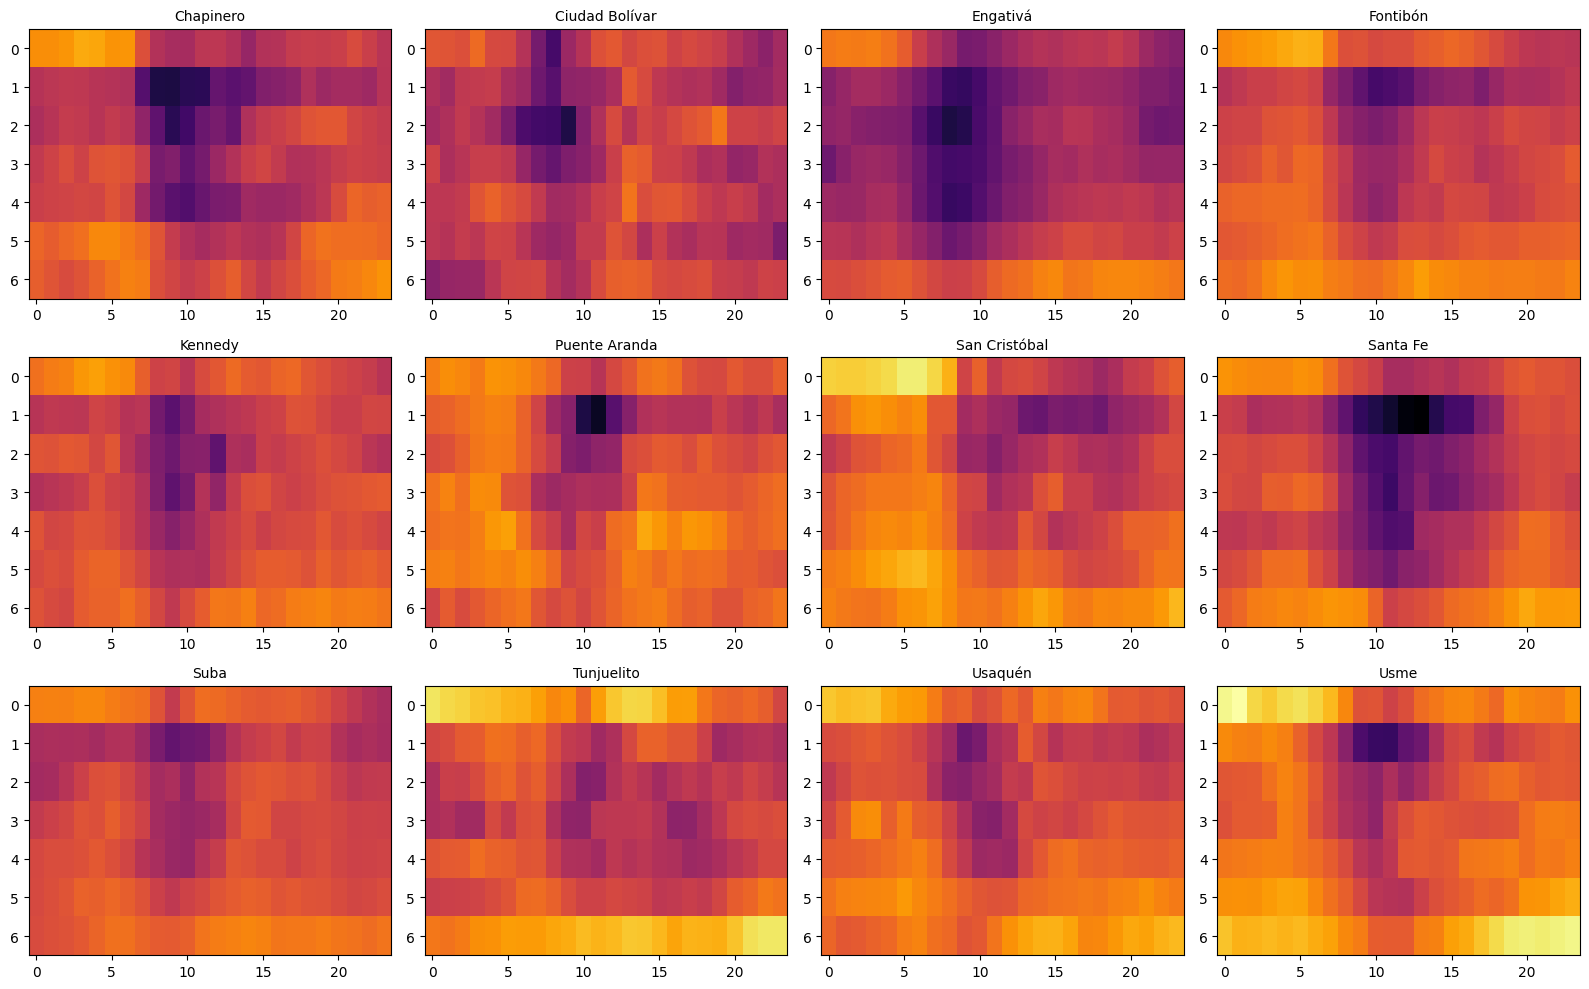

In [15]:
p6 = df.dropna(subset=["dia_semana"]).groupby(["localidad","dia_semana","hora"])["iboca"].mean().reset_index()
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, axes = plt.subplots(3,4, figsize=(16,10))
vmin, vmax = p6.iboca.min(), p6.iboca.max()
for ax, loc in zip(axes.flat, localidades):
    sub = p6[p6.localidad==loc].pivot(index="dia_semana", columns="hora", values="iboca").reindex(orden_dias)
    im = ax.imshow(sub.values, aspect="auto", cmap="inferno_r", vmin=vmin, vmax=vmax)
    ax.set_title(loc, fontsize=10)
fig.tight_layout(); plt.show()

,promedio,desviacion,coef_variacion
localidad,,,
Engativá,57.5,30.9,53.7
Puente Aranda,47.8,25.8,54.0
Chapinero,53.4,25.6,47.9
Santa Fe,53.2,25.5,47.9
Usme,45.7,25.5,55.8
Fontibón,50.1,25.3,50.5
San Cristóbal,47.6,24.5,51.5
Suba,50.5,24.2,47.9
Kennedy,50.8,23.7,46.7


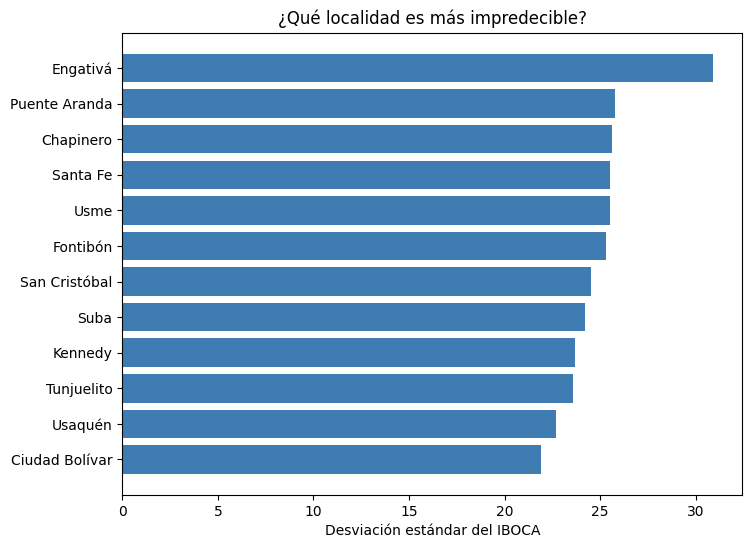

In [16]:
p7 = df.groupby("localidad")["iboca"].agg(promedio="mean", desviacion="std").round(1)
p7["coef_variacion"] = (p7["desviacion"]/p7["promedio"]*100).round(1)
p7 = p7.sort_values("desviacion", ascending=False)
display(p7)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(p7.index[::-1], p7["desviacion"][::-1], color="#3E7CB1")
ax.set_xlabel("Desviación estándar del IBOCA")
ax.set_title("¿Qué localidad es más impredecible?")
plt.show()

tipo_dia,Entre semana,Fin de semana,diferencia
localidad,,,
Engativá,60.3,50.8,-9.5
Santa Fe,55.5,47.6,-7.9
Chapinero,55.6,47.9,-7.7
Fontibón,52.2,45.2,-7.0
San Cristóbal,49.7,42.8,-6.9
Usaquén,49.4,42.7,-6.7
Tunjuelito,50.0,43.5,-6.5
Usme,47.5,41.0,-6.5
Suba,52.1,46.9,-5.2


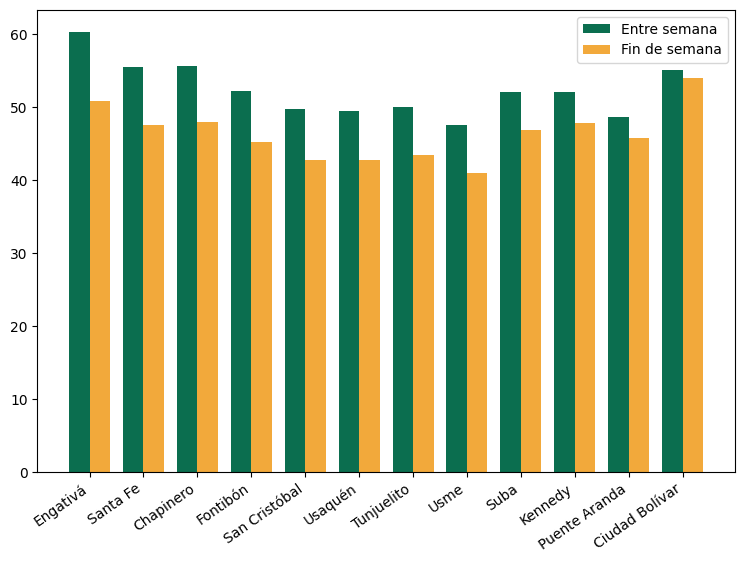

In [17]:
p8 = df.groupby(["localidad","tipo_dia"])["iboca"].mean().round(1).unstack()
p8["diferencia"] = (p8["Fin de semana"]-p8["Entre semana"]).round(1)
p8 = p8.sort_values("diferencia")
display(p8)

x = np.arange(len(p8)); w = 0.38
fig, ax = plt.subplots(figsize=(9,6))
ax.bar(x-w/2, p8["Entre semana"], width=w, label="Entre semana", color="#0B6E4F")
ax.bar(x+w/2, p8["Fin de semana"], width=w, label="Fin de semana", color="#F2A93B")
ax.set_xticks(x); ax.set_xticklabels(p8.index, rotation=35, ha="right"); ax.legend()
plt.show()

,fecha_hora,localidad,estacion,iboca,categoria_iboca
0,2025-06-04 12:00:00,Kennedy,Kennedy,298.24,Peligrosa
1,2025-06-04 14:00:00,Kennedy,Kennedy,254.90,Peligrosa
2,2025-06-04 13:00:00,Kennedy,Kennedy,206.54,Peligrosa
3,2025-01-24 14:00:00,Fontibón,Fontibon,194.58,Mala
4,2025-06-04 15:00:00,Kennedy,Kennedy,178.20,Mala
5,2025-03-01 18:00:00,Engativá,CDAR,178.19,Mala
6,2025-05-06 11:00:00,Suba,Guaymaral,173.65,Mala
7,2025-06-25 06:00:00,Engativá,CDAR,167.51,Mala
8,2025-01-24 18:00:00,Fontibón,Fontibon,166.84,Mala
9,2025-06-24 17:00:00,Fontibón,Fontibon,166.48,Mala


,localidad,horas_mala_o_peligrosa
0,Engativá,131
1,Fontibón,15
2,Suba,9
3,Kennedy,7
4,Puente Aranda,4
5,San Cristóbal,4
6,Santa Fe,4
7,Chapinero,3
8,Ciudad Bolívar,3
9,Tunjuelito,2


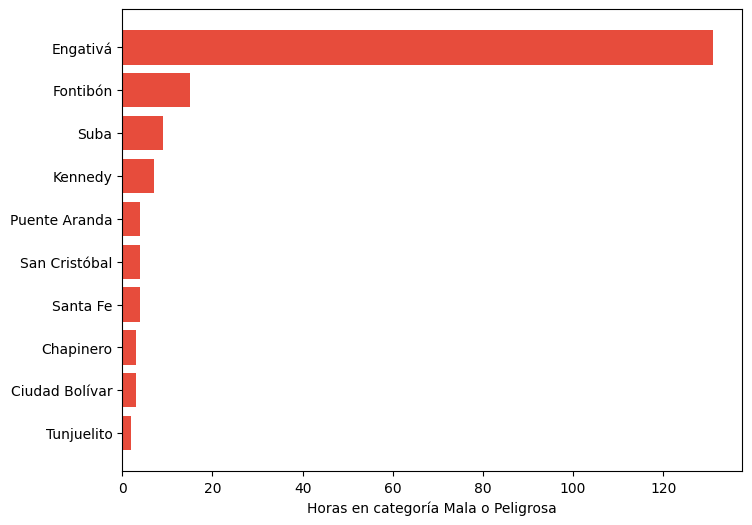

In [18]:
peores = df.dropna(subset=["iboca"]).nlargest(10, "iboca")[
    ["fecha_hora","localidad","estacion","iboca","categoria_iboca"]].reset_index(drop=True)
display(peores)

conteo_riesgo = df[df.categoria_iboca.isin(["Mala","Peligrosa"])].groupby("localidad").size().sort_values(ascending=False)
display(conteo_riesgo.reset_index(name="horas_mala_o_peligrosa"))

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(conteo_riesgo.index[::-1], conteo_riesgo.values[::-1], color="#E74C3C")
ax.set_xlabel("Horas en categoría Mala o Peligrosa")
plt.show()

,localidad,promedio,desviacion,pct_riesgo,indice_riesgo
10,Usaquén,47.52,22.66,0.00,-0.80
11,Usme,45.67,25.47,0.00,-0.56
9,Tunjuelito,48.03,23.64,0.05,-0.55
6,San Cristóbal,47.57,24.53,0.09,-0.41
5,Puente Aranda,47.82,25.78,0.05,-0.26
4,Kennedy,50.81,23.70,0.08,-0.24
8,Suba,50.55,24.24,0.07,-0.20
1,Ciudad Bolívar,54.80,21.91,0.07,-0.14
3,Fontibón,50.12,25.31,0.17,0.05
7,Santa Fe,53.23,25.48,0.09,0.27


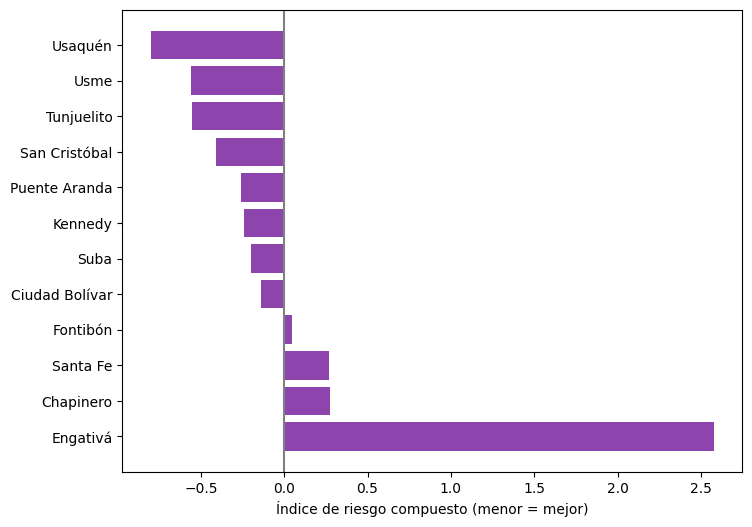

In [19]:
resumen = df.groupby("localidad")["iboca"].agg(promedio="mean", desviacion="std").reset_index()
pct_riesgo = (df[df.categoria_iboca.isin(["Mala","Peligrosa"])].groupby("localidad").size()
              / df.groupby("localidad").size() * 100).reset_index(name="pct_riesgo")
resumen = resumen.merge(pct_riesgo, on="localidad", how="left").fillna({"pct_riesgo":0})
for col in ["promedio","desviacion","pct_riesgo"]:
    resumen[f"z_{col}"] = (resumen[col]-resumen[col].mean())/resumen[col].std()
resumen["indice_riesgo"] = resumen[["z_promedio","z_desviacion","z_pct_riesgo"]].mean(axis=1)
resumen = resumen.sort_values("indice_riesgo")
display(resumen[["localidad","promedio","desviacion","pct_riesgo","indice_riesgo"]].round(2))

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(resumen["localidad"][::-1], resumen["indice_riesgo"][::-1], color="#8E44AD")
ax.axvline(0, color="grey")
ax.set_xlabel("Índice de riesgo compuesto (menor = mejor)")
plt.show()

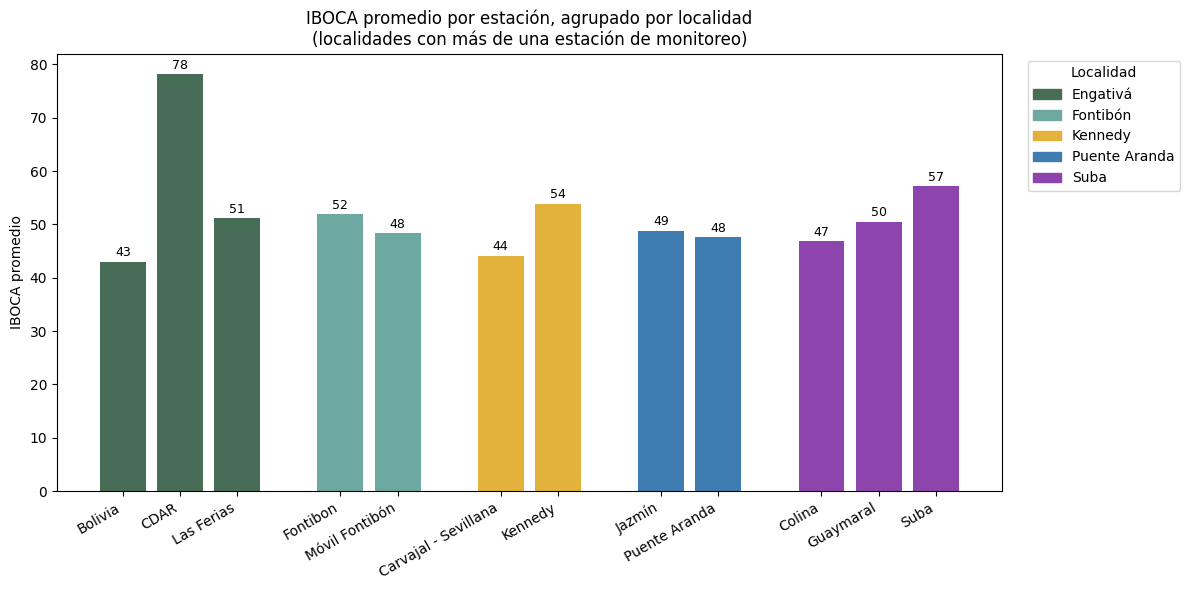

In [20]:
localidades_varias = df.groupby("localidad")["estacion"].nunique()
localidades_varias = localidades_varias[localidades_varias > 1].index.tolist()

promedios = (df[df.localidad.isin(localidades_varias)]
             .groupby(["localidad", "estacion"])["iboca"]
             .mean().round(1).reset_index())

colores_localidad = {"Engativá": "#476d56", "Fontibón": "#6da9a1", "Kennedy": "#e3b23c",
                      "Puente Aranda": "#3E7CB1", "Suba": "#8E44AD"}

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = 0
xticks, xlabels = [], []
for loc in localidades_varias:
    sub = promedios[promedios.localidad == loc].sort_values("estacion")
    for _, row in sub.iterrows():
        ax.bar(x_pos, row["iboca"], color=colores_localidad[loc], width=0.8)
        ax.text(x_pos, row["iboca"] + 1, f'{row["iboca"]:.0f}', ha="center", fontsize=9)
        xticks.append(x_pos)
        xlabels.append(row["estacion"])
        x_pos += 1
    x_pos += 0.8  # espacio entre localidades

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=30, ha="right")
ax.set_ylabel("IBOCA promedio")
ax.set_title("IBOCA promedio por estación, agrupado por localidad\n(localidades con más de una estación de monitoreo)")

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colores_localidad.values()]
ax.legend(handles, colores_localidad.keys(), title="Localidad", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

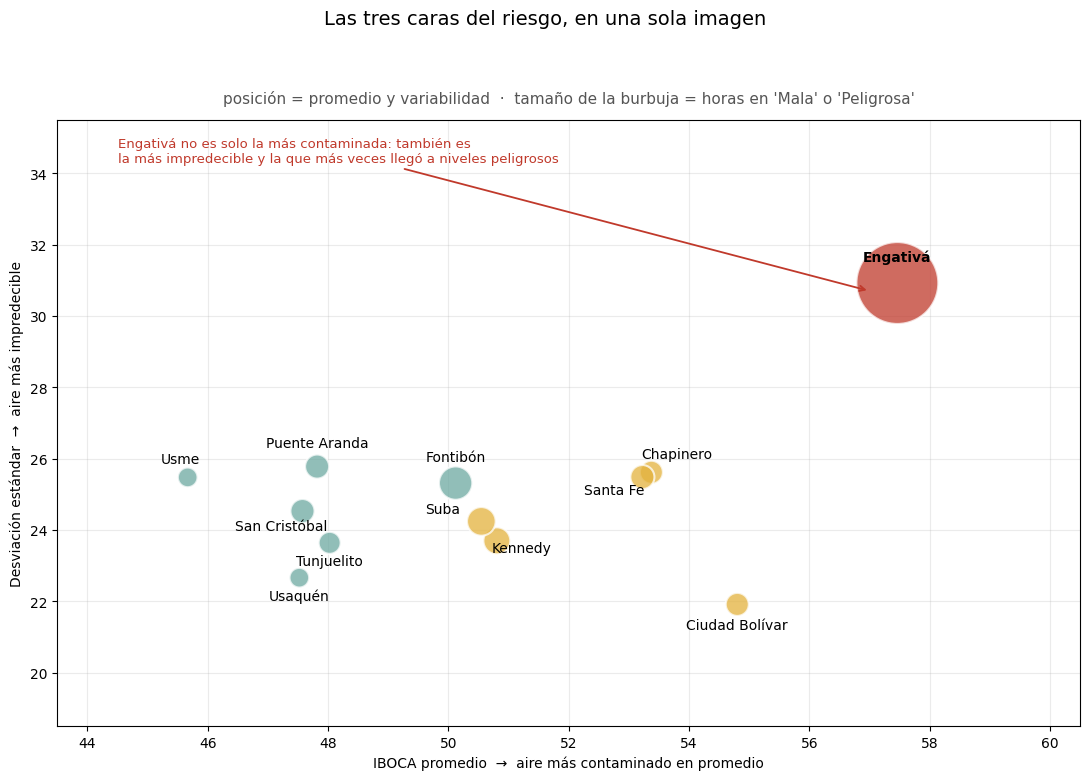

In [23]:
import matplotlib.pyplot as plt
import numpy as np

resumen = df.groupby("localidad")["iboca"].agg(promedio="mean", desviacion="std").reset_index()
horas_riesgo = (df[df.categoria_iboca.isin(["Mala","Peligrosa"])]
                .groupby("localidad").size().reindex(resumen["localidad"]).fillna(0).values)
resumen["horas_riesgo"] = horas_riesgo

fig, ax = plt.subplots(figsize=(11, 8))

tamanos = 200 + resumen["horas_riesgo"] * 25
colores = np.where(resumen["promedio"] > resumen["promedio"].median(), "#e3b23c", "#6da9a1")
colores = np.where(resumen["horas_riesgo"] > 50, "#c0392b", colores)

ax.scatter(resumen["promedio"], resumen["desviacion"], s=tamanos,
           c=colores, alpha=0.75, edgecolors="white", linewidth=1.5, zorder=3)

# Desplazamientos manuales (dx, dy en puntos) para que las etiquetas no se encimen
offsets = {
    "Usme": (-5, 10), "Puente Aranda": (0, 14), "Fontibón": (0, 16),
    "San Cristóbal": (-15, -14), "Tunjuelito": (0, -16), "Usaquén": (0, -16),
    "Suba": (-28, 6), "Kennedy": (18, -8),
    "Chapinero": (18, 10), "Santa Fe": (-20, -12),
    "Ciudad Bolívar": (0, -18), "Engativá": (0, 16),
}
for _, row in resumen.iterrows():
    dx, dy = offsets.get(row["localidad"], (0, 12))
    ax.annotate(row["localidad"], (row["promedio"], row["desviacion"]),
                xytext=(dx, dy), textcoords="offset points",
                ha="center", fontsize=10,
                fontweight="bold" if row["horas_riesgo"] > 50 else "normal", zorder=4)

ax.set_xlabel("IBOCA promedio  →  aire más contaminado en promedio")
ax.set_ylabel("Desviación estándar  →  aire más impredecible")
ax.grid(alpha=0.25)
ax.set_xlim(43.5, 60.5)
ax.set_ylim(18.5, 35.5)

fig.suptitle("Las tres caras del riesgo, en una sola imagen", fontsize=14, y=0.97)
ax.set_title("posición = promedio y variabilidad  ·  tamaño de la burbuja = horas en 'Mala' o 'Peligrosa'",
             fontsize=11, color="#555555", pad=12)

ax.annotate("Engativá no es solo la más contaminada: también es\nla más impredecible y la que más veces llegó a niveles peligrosos",
            xy=(57.0, 30.7), xytext=(44.5, 34.3),
            fontsize=9.5, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.3))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()